# Tugas: Feature Selection & Feature Engineering
## Dataset: Marvel Characters Dataset
**Mata Kuliah:** Introduction to AI  
**Dataset:** `marvel_characters_dataset.csv`

---
Notebook ini mengimplementasikan **Feature Selection** dan **Feature Engineering** menggunakan dataset karakter Marvel.

**Tahapan yang dikerjakan:**
1. Load Dataset & Eksplorasi Awal
2. Feature Engineering: Missing Value Handling
3. Feature Engineering: One-Hot Encoding
4. Feature Engineering: Feature Scaling
5. Feature Selection: Correlation Heatmap
6. Feature Selection: Univariate Feature Selection (SelectKBest)
7. Feature Selection: Recursive Feature Elimination (RFE)

## 1. Load Dataset & Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('marvel_characters_dataset.csv')

print("Shape dataset:", df.shape)
print("\n5 baris pertama:")
df.head()

Shape dataset: (45, 6)

5 baris pertama:


,Character,Real Name,Affiliation,Powers,Role,Power Level
0,iron man,Tony Stark,Avengers,"Powered Armor, Genius-level intellect",Hero,Low
1,captain america,Steve Rogers,Avengers,"Super Soldier, Enhanced strength",Hero,Low
2,thor,Thor Odinson,Avengers,"God of Thunder, Weather manipulation",Hero,Low
3,black widow,Natasha Romanoff,Avengers,"Superhuman strength, Espionage",Hero,Low
4,hulk,Bruce Banner,Avengers,"Superhuman strength, Gamma Radiation",Hero,Low


In [2]:
print("Tipe data tiap kolom:")
print(df.dtypes)
print("\nJumlah nilai unik per kolom:")
print(df.nunique())

Tipe data tiap kolom:
Character      object
Real Name      object
Affiliation    object
Powers         object
Role           object
Power Level    object
dtype: object

Jumlah nilai unik per kolom:
Character      44
Real Name      41
Affiliation    10
Powers         38
Role            3
Power Level     1
dtype: int64


## 2. Feature Engineering — Missing Value Handling

Dataset Marvel memiliki semua kolom bertipe teks (kategorikal). Kita cek apakah ada nilai yang hilang, lalu tangani dengan strategi yang sesuai.

In [3]:
# Cek missing values
print("Jumlah missing values per kolom:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Jumlah missing values per kolom:
Character      0
Real Name      0
Affiliation    0
Powers         0
Role           0
Power Level    0
dtype: int64

Total missing values: 0


In [4]:
# Simulasi missing values agar proses imputation dapat didemonstrasikan
df_missing = df.copy()
np.random.seed(42)
for col in ['Affiliation', 'Powers']:
    idx = np.random.choice(df_missing.index, size=3, replace=False)
    df_missing.loc[idx, col] = np.nan

print("Missing values setelah simulasi:")
print(df_missing.isnull().sum())

# Imputation: isi dengan mode (nilai terbanyak) untuk kolom kategorikal
for col in df_missing.columns:
    if df_missing[col].isnull().any():
        mode_val = df_missing[col].mode()[0]
        df_missing[col].fillna(mode_val, inplace=True)
        print(f"Kolom '{col}' diisi dengan mode: '{mode_val}'")

print("\nMissing values setelah imputation:")
print(df_missing.isnull().sum())

Missing values setelah simulasi:
Character      0
Real Name      0
Affiliation    3
Powers         3
Role           0
Power Level    0
dtype: int64
Kolom 'Affiliation' diisi dengan mode: 'Avengers'
Kolom 'Powers' diisi dengan mode: 'Superhuman strength, Durability'

Missing values setelah imputation:
Character      0
Real Name      0
Affiliation    0
Powers         0
Role           0
Power Level    0
dtype: int64


**Interpretasi:**  
Dataset Marvel tidak memiliki missing values secara asli. Kita mensimulasikan 3 missing values pada kolom `Affiliation` dan `Powers`, kemudian mengisi dengan **mode** (nilai yang paling sering muncul) karena kedua kolom bertipe kategorikal. Strategi mode cocok untuk data teks karena tidak ada konsep rata-rata atau median pada data non-numerik.

## 3. Feature Engineering — One-Hot Encoding

Sebagian besar kolom dalam dataset ini bersifat kategorikal. Algoritma machine learning membutuhkan data numerik, sehingga kita perlu mengubah kolom kategorikal menjadi format biner menggunakan **One-Hot Encoding**.

In [5]:
# One-Hot Encoding pada kolom 'Affiliation' dan 'Role'
df_encoded = df.copy()

# Tampilkan sebelum encoding
print("Sebelum One-Hot Encoding:")
print(df_encoded[['Affiliation', 'Role']].head())
print("Shape:", df_encoded.shape)

# Terapkan get_dummies hanya pada kolom terpilih
df_encoded = pd.get_dummies(df_encoded, columns=['Affiliation', 'Role'], drop_first=False)

# Tampilkan kolom baru yang dihasilkan
new_cols = [c for c in df_encoded.columns if 'Affiliation_' in c or 'Role_' in c]
print("\nKolom baru hasil One-Hot Encoding:")
print(new_cols)
print("\nShape setelah encoding:", df_encoded.shape)
df_encoded[new_cols].head()

Sebelum One-Hot Encoding:
  Affiliation  Role
0    Avengers  Hero
1    Avengers  Hero
2    Avengers  Hero
3    Avengers  Hero
4    Avengers  Hero
Shape: (45, 6)

Kolom baru hasil One-Hot Encoding:
['Affiliation_Avengers', 'Affiliation_Defenders', 'Affiliation_Fantastic Four', 'Affiliation_Guardians of the Galaxy', 'Affiliation_Hydra', 'Affiliation_Inhumans', 'Affiliation_Sinister Six', 'Affiliation_Villain', 'Affiliation_X-Force', 'Affiliation_X-Men', 'Role_Antihero', 'Role_Hero', 'Role_Villain']

Shape setelah encoding: (45, 17)


,Affiliation_Avengers,Affiliation_Defenders,Affiliation_Fantastic Four,Affiliation_Guardians of the Galaxy,Affiliation_Hydra,Affiliation_Inhumans,Affiliation_Sinister Six,Affiliation_Villain,Affiliation_X-Force,Affiliation_X-Men,Role_Antihero,Role_Hero,Role_Villain
0,True,False,False,False,False,False,False,False,False,False,False,True,False
1,True,False,False,False,False,False,False,False,False,False,False,True,False
2,True,False,False,False,False,False,False,False,False,False,False,True,False
3,True,False,False,False,False,False,False,False,False,False,False,True,False
4,True,False,False,False,False,False,False,False,False,False,False,True,False


**Interpretasi:**  
Kolom `Affiliation` (Avengers, X-Men, dll.) dan `Role` (Hero, Villain, Antihero) diubah menjadi kolom biner. Setiap kategori mendapat kolom tersendiri bernilai 1 jika karakter termasuk kategori itu, dan 0 jika tidak. Jumlah kolom bertambah sesuai jumlah kategori unik. Pendekatan ini mencegah model salah menginterpretasikan label kategori sebagai nilai numerik yang berurutan.

## 4. Feature Engineering — Feature Scaling

Kita buat fitur numerik terlebih dahulu dari kolom `Powers` (menghitung jumlah kekuatan tiap karakter), lalu terapkan **StandardScaler** dan **MinMaxScaler**.

In [6]:
# Buat fitur numerik dari kolom teks
df_num = df.copy()

# Fitur 1: jumlah kekuatan (power_count) — hitung koma + 1
df_num['power_count'] = df_num['Powers'].apply(lambda x: len(str(x).split(',')) )

# Fitur 2: panjang nama karakter (name_length)
df_num['name_length'] = df_num['Character'].apply(lambda x: len(str(x)))

# Fitur 3: panjang afiliasi (affil_length)
df_num['affil_length'] = df_num['Affiliation'].apply(lambda x: len(str(x)))

print("Fitur numerik sebelum scaling:")
print(df_num[['power_count', 'name_length', 'affil_length']].describe())

# Terapkan StandardScaler
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(df_num[['power_count', 'name_length', 'affil_length']])
df_std = pd.DataFrame(X_std, columns=['power_count', 'name_length', 'affil_length'])

# Terapkan MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(df_num[['power_count', 'name_length', 'affil_length']])
df_mm = pd.DataFrame(X_mm, columns=['power_count', 'name_length', 'affil_length'])

print("\nSetelah StandardScaler (mean~0, std~1):")
print(df_std.describe().round(2))

print("\nSetelah MinMaxScaler (range 0–1):")
print(df_mm.describe().round(2))

Fitur numerik sebelum scaling:
       power_count  name_length  affil_length
count    45.000000    45.000000     45.000000
mean      1.977778     9.200000      9.755556
std       0.336350     3.454904      4.184145
min       1.000000     4.000000      5.000000
25%       2.000000     6.000000      8.000000
50%       2.000000     9.000000      8.000000
75%       2.000000    12.000000      9.000000
max       3.000000    16.000000     23.000000

Setelah StandardScaler (mean~0, std~1):
       power_count  name_length  affil_length
count        45.00        45.00         45.00
mean         -0.00         0.00         -0.00
std           1.01         1.01          1.01
min          -2.94        -1.52         -1.15
25%           0.07        -0.94         -0.42
50%           0.07        -0.06         -0.42
75%           0.07         0.82         -0.18
max           3.07         1.99          3.20

Setelah MinMaxScaler (range 0–1):
       power_count  name_length  affil_length
count        45.00 

**Interpretasi:**  
Tiga fitur numerik dibuat dari data teks: `power_count` (jumlah kekuatan per karakter), `name_length` (panjang nama), dan `affil_length` (panjang nama afiliasi). Ketiga fitur ini memiliki skala berbeda.  
- **StandardScaler** menggeser distribusi menjadi mean ≈ 0 dan std ≈ 1 — cocok untuk algoritma berbasis jarak seperti SVM dan KNN.  
- **MinMaxScaler** mengubah semua nilai ke rentang 0–1 — cocok untuk neural network.  
Scaling mencegah fitur dengan nilai besar mendominasi proses training.

---
## 5. Feature Selection — Correlation Heatmap

Setelah memiliki fitur numerik, kita visualisasikan korelasi antar fitur menggunakan **Correlation Heatmap** untuk mengidentifikasi fitur yang redundan.

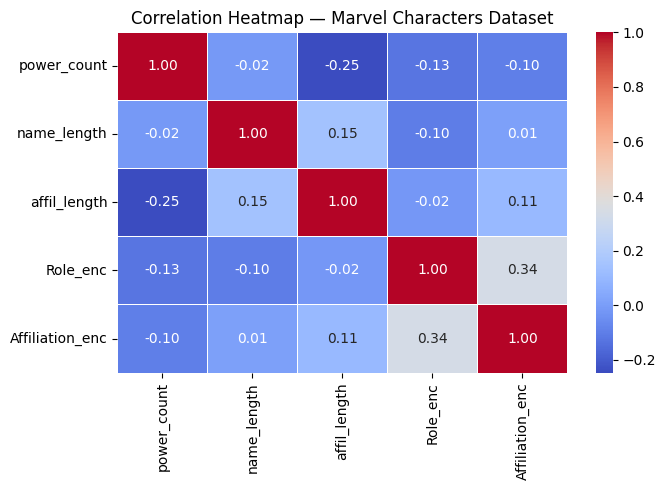

                 power_count  name_length  affil_length  Role_enc  \
power_count             1.00        -0.02         -0.25     -0.13   
name_length            -0.02         1.00          0.15     -0.10   
affil_length           -0.25         0.15          1.00     -0.02   
Role_enc               -0.13        -0.10         -0.02      1.00   
Affiliation_enc        -0.10         0.01          0.11      0.34   

                 Affiliation_enc  
power_count                -0.10  
name_length                 0.01  
affil_length                0.11  
Role_enc                    0.34  
Affiliation_enc             1.00  


In [8]:
# Encode semua fitur kategorikal menjadi numerik untuk keperluan korelasi
df_corr = df.copy()
df_corr['power_count'] = df_corr['Powers'].apply(lambda x: len(str(x).split(',')))
df_corr['name_length']  = df_corr['Character'].apply(lambda x: len(str(x)))
df_corr['affil_length'] = df_corr['Affiliation'].apply(lambda x: len(str(x)))

le = LabelEncoder()
df_corr['Role_enc']        = le.fit_transform(df_corr['Role'])
df_corr['Affiliation_enc'] = le.fit_transform(df_corr['Affiliation'])

# Catatan: kolom 'Power Level' tidak dimasukkan karena semua nilainya 'Low' (variance = 0)
num_cols = ['power_count', 'name_length', 'affil_length',
            'Role_enc', 'Affiliation_enc']

corr_matrix = df_corr[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Marvel Characters Dataset')
plt.tight_layout()
plt.show()
print(corr_matrix.round(2))

**Interpretasi:**  
Dari heatmap korelasi:
- Nilai korelasi mendekati **+1** (merah tua) menunjukkan korelasi positif kuat — kedua fitur bergerak searah.  
- Nilai mendekati **-1** (biru tua) menunjukkan korelasi negatif kuat.  
- Nilai mendekati **0** menunjukkan fitur bersifat independen satu sama lain.  

Fitur-fitur yang memiliki korelasi sangat tinggi (> 0.9) bersifat redundan dan salah satunya dapat dihilangkan untuk mengurangi dimensionalitas tanpa kehilangan informasi penting.

## 6. Feature Selection — Univariate Feature Selection (SelectKBest)

Menggunakan **SelectKBest** dengan uji statistik `f_classif` untuk memilih fitur-fitur yang paling relevan terhadap target variabel (`Role_enc`: Hero/Villain/Antihero).

Skor tiap fitur (f_classif):
  Affiliation_enc        skor = 7.9083 ✓ TERPILIH
  name_length            skor = 1.9051 ✓ TERPILIH
  affil_length           skor = 0.5003 ✓ TERPILIH
  power_count            skor = 0.4427

Fitur terpilih (top 3): ['name_length', 'affil_length', 'Affiliation_enc']
Shape data setelah seleksi: (45, 3)


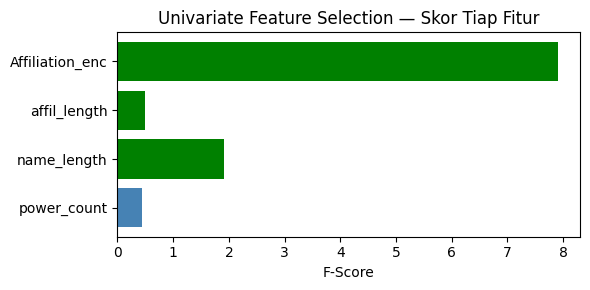

In [10]:
# Fitur input (X) dan target (y)
feature_names = ['power_count', 'name_length', 'affil_length', 'Affiliation_enc']
X = df_corr[feature_names].values
y = df_corr['Role_enc'].values

# SelectKBest: pilih 3 fitur terbaik
selector = SelectKBest(score_func=f_classif, k=3)
X_selected = selector.fit_transform(X, y)

# Tampilkan skor tiap fitur
scores = selector.scores_
print("Skor tiap fitur (f_classif):")
sorted_pairs = sorted(zip(feature_names, scores), key=lambda x: x[1], reverse=True)
threshold = sorted(scores, reverse=True)[2]
for name, score in sorted_pairs:
    marker = " ✓ TERPILIH" if score >= threshold else ""
    print(f"  {name:<22} skor = {score:.4f}{marker}")

selected_features = [feature_names[i] for i in selector.get_support(indices=True)]
print(f"\nFitur terpilih (top 3): {selected_features}")
print(f"Shape data setelah seleksi: {X_selected.shape}")

# Visualisasi skor fitur
plt.figure(figsize=(6, 3))
colors = ['green' if f in selected_features else 'steelblue' for f in feature_names]
plt.barh(feature_names, scores, color=colors)
plt.xlabel('F-Score')
plt.title('Univariate Feature Selection — Skor Tiap Fitur')
plt.tight_layout()
plt.show()

**Interpretasi:**  
SelectKBest mengevaluasi setiap fitur secara **individual** terhadap target `Role` menggunakan uji ANOVA F-test. Fitur dengan **F-score tinggi** memiliki hubungan statistik yang lebih kuat dengan target. Tiga fitur terpilih (ditandai hijau) adalah yang paling relevan untuk membedakan Hero, Villain, dan Antihero. Fitur dengan skor rendah kurang informatif secara statistik dan dapat dihilangkan dari model.

## 7. Feature Selection — Recursive Feature Elimination (RFE)

**RFE** bekerja dengan melatih model secara berulang, lalu mengeliminasi fitur yang paling tidak penting pada setiap iterasi, hingga tersisa jumlah fitur yang diinginkan.

In [11]:
# Normalisasi fitur sebelum RFE (wajib untuk Logistic Regression)
from sklearn.preprocessing import StandardScaler
X_scaled_rfe = StandardScaler().fit_transform(X)

# RFE dengan Logistic Regression, pilih 3 fitur terbaik
model_lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=model_lr, n_features_to_select=3)
rfe.fit(X_scaled_rfe, y)

# Tampilkan hasil
print("Hasil RFE:")
print(f"{'Fitur':<22} {'Dipilih':<10} {'Ranking'}")
print("-" * 40)
for name, support, rank in zip(feature_names, rfe.support_, rfe.ranking_):
    status = "✓ Ya" if support else "✗ Tidak"
    print(f"{name:<22} {status:<10} {rank}")

rfe_selected = [f for f, s in zip(feature_names, rfe.support_) if s]
print(f"\nFitur terpilih RFE: {rfe_selected}")

# Perbandingan SelectKBest vs RFE
print("\n--- Perbandingan Metode ---")
print(f"SelectKBest (top 3) : {selected_features}")
print(f"RFE (top 3)         : {rfe_selected}")
common = list(set(selected_features) & set(rfe_selected))
print(f"Fitur yang sama     : {common}")

Hasil RFE:
Fitur                  Dipilih    Ranking
----------------------------------------
power_count            ✗ Tidak    2
name_length            ✓ Ya       1
affil_length           ✓ Ya       1
Affiliation_enc        ✓ Ya       1

Fitur terpilih RFE: ['name_length', 'affil_length', 'Affiliation_enc']

--- Perbandingan Metode ---
SelectKBest (top 3) : ['name_length', 'affil_length', 'Affiliation_enc']
RFE (top 3)         : ['name_length', 'affil_length', 'Affiliation_enc']
Fitur yang sama     : ['affil_length', 'Affiliation_enc', 'name_length']


**Interpretasi:**  
RFE menggunakan **Logistic Regression** sebagai estimator dan secara iteratif mengeliminasi fitur paling lemah. Fitur dengan **ranking = 1** adalah fitur yang dipertahankan hingga akhir, artinya paling berkontribusi terhadap prediksi `Role`.  

Perbandingan dengan SelectKBest:
- **SelectKBest** mengevaluasi tiap fitur secara statistik secara **independen** (tanpa model).  
- **RFE** mengevaluasi fitur berdasarkan **kontribusi nyata terhadap model** secara rekursif.  
- Fitur yang dipilih oleh **kedua metode** adalah fitur yang paling kuat secara statistik **dan** secara model — inilah set fitur yang paling direkomendasikan untuk digunakan.

---
## Kesimpulan

| Teknik | Kategori | Hasil |
|--------|----------|-------|
| Missing Value Handling (Mode Imputation) | Feature Engineering | Nilai hilang pada kolom kategorikal diisi dengan modus |
| One-Hot Encoding | Feature Engineering | Kolom `Affiliation` & `Role` diubah menjadi fitur biner |
| Feature Scaling (Standard & MinMax) | Feature Engineering | Fitur numerik diseragamkan skalanya |
| Correlation Heatmap | Feature Selection | Visualisasi fitur redundan antar kolom |
| SelectKBest (f_classif) | Feature Selection | Pemilihan fitur berdasarkan skor statistik F |
| RFE (Logistic Regression) | Feature Selection | Pemilihan fitur berdasarkan rekursif eliminasi model |

Kombinasi Feature Engineering dan Feature Selection menghasilkan dataset yang lebih bersih, lebih informatif, dan siap untuk digunakan melatih model machine learning secara optimal.